# Heart Disease Prediction

## Goal
The goal of this project is to use patient health-related features to predict whether heart disease is absent or present, using the UCI Heart Disease dataset.

## Learning goals
- practice classification
- clean a real dataset
- compare multiple models
- understand evaluation metrics

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [3]:
heart_disease = fetch_ucirepo(id=45)

X_raw = heart_disease.data.features.copy()
y_raw = heart_disease.data.targets.copy()

df = pd.concat([X_raw, y_raw], axis=1)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [4]:
df.shape

(303, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [7]:
df.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
236,56,1,4,130,283,1,2,103,1,1.6,3,0.0,7.0,2
239,42,1,2,120,295,0,0,162,0,0.0,1,0.0,3.0,0
105,54,1,2,108,309,0,0,156,0,0.0,1,0.0,7.0,0
94,63,0,3,135,252,0,2,172,0,0.0,1,0.0,3.0,0
266,52,1,4,128,204,1,0,156,1,1.0,2,0.0,NaN,2


In [8]:
df.isnull().sum().sort_values(ascending=False)

ca          4
thal        2
cp          0
trestbps    0
age         0
sex         0
fbs         0
chol        0
restecg     0
thalach     0
oldpeak     0
exang       0
slope       0
num         0
dtype: int64

In [9]:
df.describe(include="all")

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


## Initial observations
- The dataset contains patient-level records.
- The target column is `num`.
- The columns ca and thal have missing values.
- Some columns may need type conversion or cleaning.
- Several predictors are coded categories, not ordinary numbers.

In [10]:
df["target"] = (df["num"] > 0).astype(int)

In [11]:
df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

In [12]:
df["target"].value_counts(normalize=True)

target
0    0.541254
1    0.458746
Name: proportion, dtype: float64

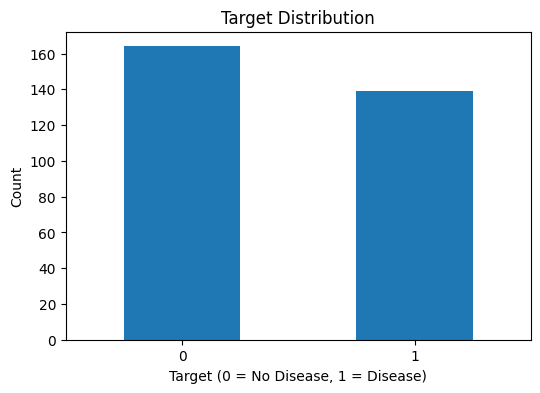

In [13]:
df["target"].value_counts().sort_index().plot(kind="bar", figsize=(6,4))
plt.title("Target Distribution")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [14]:
df_clean = df.copy()

In [15]:
df_clean = df_clean.replace("?", np.nan)

In [16]:
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

In [17]:
df_clean.isnull().sum().sort_values(ascending=False)

ca          4
thal        2
age         0
trestbps    0
chol        0
sex         0
cp          0
restecg     0
fbs         0
thalach     0
exang       0
slope       0
oldpeak     0
num         0
target      0
dtype: int64

In [18]:
df_clean = df_clean.dropna().copy()

In [20]:
df_clean.shape

(297, 15)

## Cleaning decisions
- Replaced placeholder missing values with NaN
- Converted columns to numeric
- Dropped rows with missing values for a simpler first model
- Converted the original target into a binary label

In [21]:
df_clean.groupby("target")[["age", "trestbps", "chol", "thalach", "oldpeak"]].mean()

,age,trestbps,chol,thalach,oldpeak
target,,,,,
0,52.643750,129.175000,243.493750,158.581250,0.598750
1,56.759124,134.635036,251.854015,139.109489,1.589051


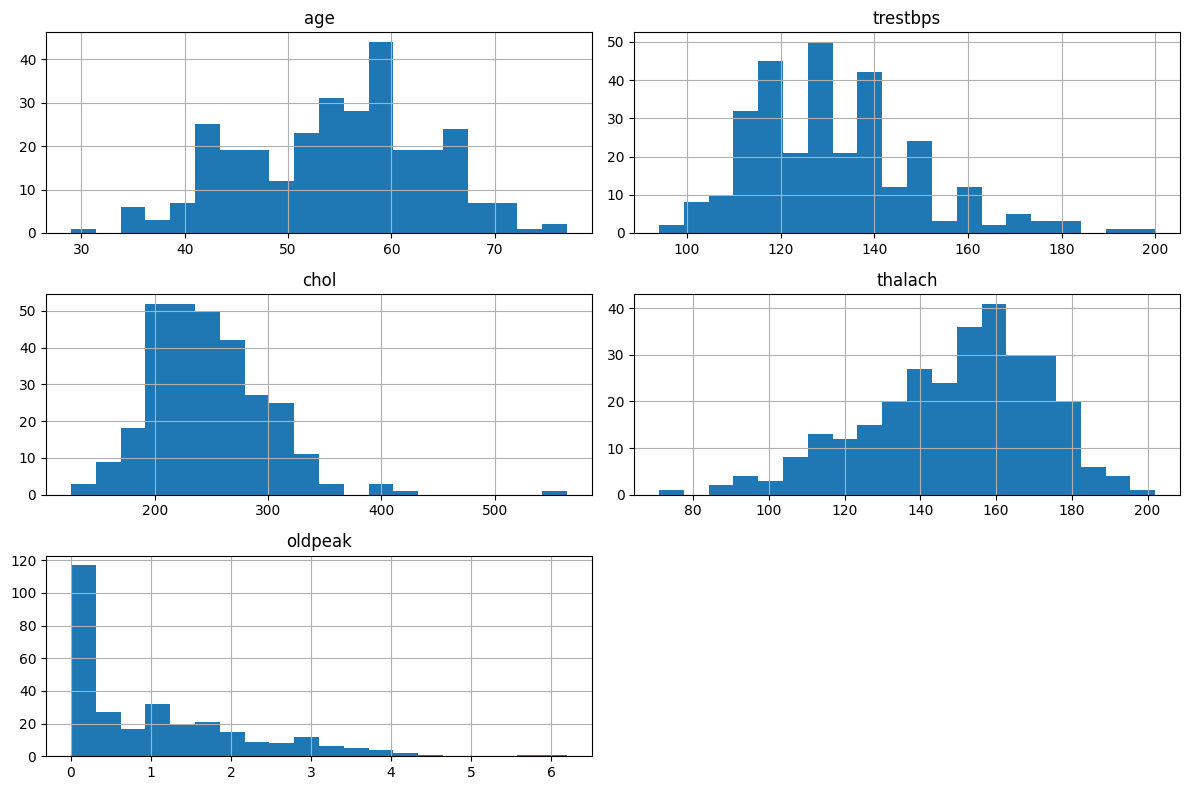

In [22]:
df_clean[["age", "trestbps", "chol", "thalach", "oldpeak"]].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

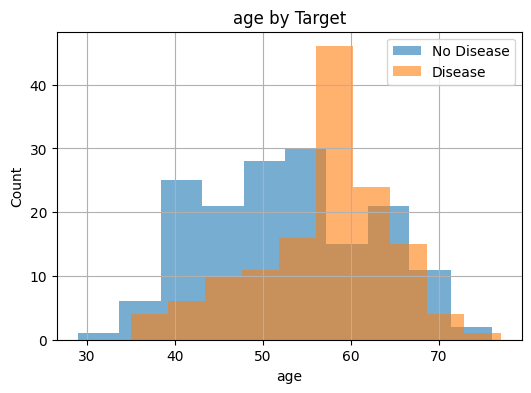

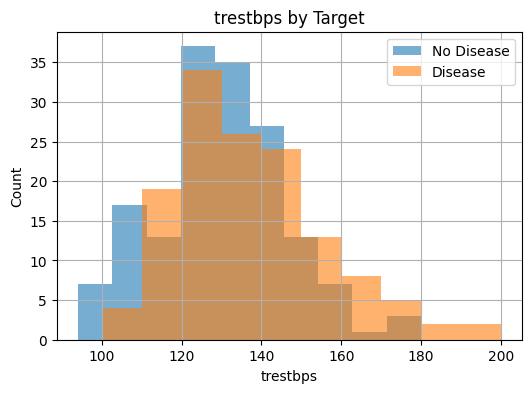

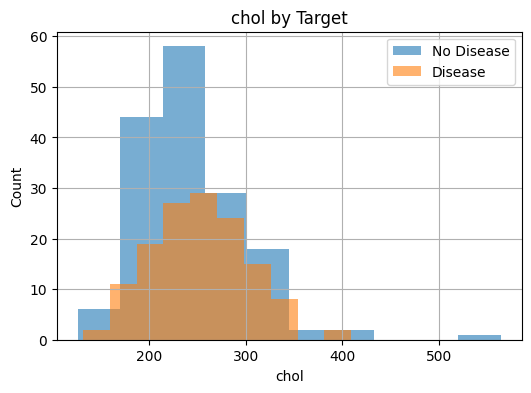

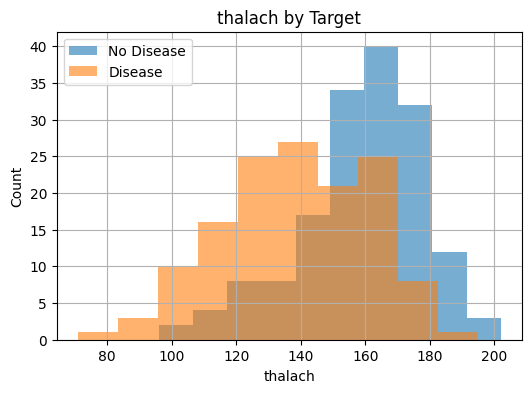

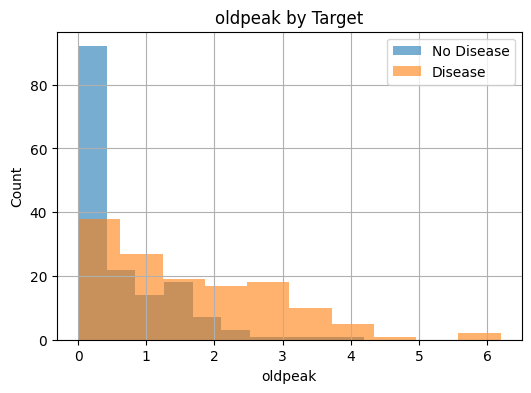

In [23]:
for col in ["age", "trestbps", "chol", "thalach", "oldpeak"]:
    plt.figure(figsize=(6,4))
    df_clean[df_clean["target"] == 0][col].hist(alpha=0.6, label="No Disease")
    df_clean[df_clean["target"] == 1][col].hist(alpha=0.6, label="Disease")
    plt.title(f"{col} by Target")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

In [24]:
feature_cols = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal"
]

df_model = df_clean[feature_cols + ["target"]].copy()
df_model.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [25]:
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

X = pd.get_dummies(
    df_model[categorical_cols + numeric_cols],
    columns=categorical_cols,
    drop_first=True
)

y = df_model["target"]

In [26]:
X.head()

,age,trestbps,chol,thalach,oldpeak,sex_1,cp_2,cp_3,cp_4,fbs_1,restecg_1,restecg_2,exang_1,slope_2,slope_3,ca_1.0,ca_2.0,ca_3.0,thal_6.0,thal_7.0
0,63,145,233,150,2.3,True,False,False,False,True,False,True,False,False,True,False,False,False,True,False
1,67,160,286,108,1.5,True,False,False,True,False,False,True,True,True,False,False,False,True,False,False
2,67,120,229,129,2.6,True,False,False,True,False,False,True,True,True,False,False,True,False,False,True
3,37,130,250,187,3.5,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False
4,41,130,204,172,1.4,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False


In [27]:
X.shape

(297, 20)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((237, 20), (60, 20), (237,), (60,))

## Purpose of this:
- training the model on X_train, y_train
- model will be tested on X_test, y_test
- random_state=42 makes results reproducible
- stratify=y helps keep the class proportions similar in train and test.

In [35]:
dummy = DummyClassifier(strategy="prior")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)
dummy_prob = dummy.predict_proba(X_test)[:, 1]

In [36]:
print("Dummy Accuracy:", accuracy_score(y_test, dummy_pred))
print("Dummy Precision:", precision_score(y_test, dummy_pred, zero_division=0))
print("Dummy Recall:", recall_score(y_test, dummy_pred, zero_division=0))
print("Dummy F1:", f1_score(y_test, dummy_pred, zero_division=0))
print("Dummy ROC-AUC:", roc_auc_score(y_test, dummy_prob))

Dummy Accuracy: 0.5333333333333333
Dummy Precision: 0.0
Dummy Recall: 0.0
Dummy F1: 0.0
Dummy ROC-AUC: 0.5


In [37]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

log_pred = log_reg.predict(X_test_scaled)
log_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

In [39]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("Logistic Regression Precision:", precision_score(y_test, log_pred))
print("Logistic Regression Recall:", recall_score(y_test, log_pred))
print("Logistic Regression F1:", f1_score(y_test, log_pred))
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, log_prob))

Logistic Regression Accuracy: 0.8333333333333334
Logistic Regression Precision: 0.8461538461538461
Logistic Regression Recall: 0.7857142857142857
Logistic Regression F1: 0.8148148148148148
Logistic Regression ROC-AUC: 0.9397321428571428


In [40]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85        32
           1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



In [49]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)
tree_prob = tree.predict_proba(X_test)[:, 1]

In [50]:
print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))
print("Decision Tree Precision:", precision_score(y_test, tree_pred))
print("Decision Tree Recall:", recall_score(y_test, tree_pred))
print("Decision Tree F1:", f1_score(y_test, tree_pred))
print("Decision Tree ROC-AUC:", roc_auc_score(y_test, tree_prob))

Decision Tree Accuracy: 0.7666666666666667
Decision Tree Precision: 0.85
Decision Tree Recall: 0.6071428571428571
Decision Tree F1: 0.7083333333333334
Decision Tree ROC-AUC: 0.8058035714285715


In [51]:
forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
forest.fit(X_train, y_train)

forest_pred = forest.predict(X_test)
forest_prob = forest.predict_proba(X_test)[:, 1]

In [52]:
print("Random Forest Accuracy:", accuracy_score(y_test, forest_pred))
print("Random Forest Precision:", precision_score(y_test, forest_pred))
print("Random Forest Recall:", recall_score(y_test, forest_pred))
print("Random Forest F1:", f1_score(y_test, forest_pred))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, forest_prob))

Random Forest Accuracy: 0.8166666666666667
Random Forest Precision: 0.8148148148148148
Random Forest Recall: 0.7857142857142857
Random Forest F1: 0.8
Random Forest ROC-AUC: 0.9090401785714286


In [53]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob)
    }

results = pd.DataFrame([
    evaluate_model("Dummy", y_test, dummy_pred, dummy_prob),
    evaluate_model("Logistic Regression", y_test, log_pred, log_prob),
    evaluate_model("Decision Tree", y_test, tree_pred, tree_prob),
    evaluate_model("Random Forest", y_test, forest_pred, forest_prob),
])

results.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Logistic Regression,0.833333,0.846154,0.785714,0.814815,0.939732
3,Random Forest,0.816667,0.814815,0.785714,0.800000,0.909040
2,Decision Tree,0.766667,0.850000,0.607143,0.708333,0.805804
0,Dummy,0.533333,0.000000,0.000000,0.000000,0.500000


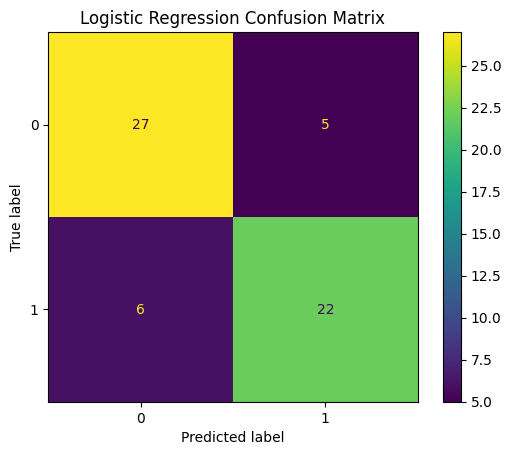

In [54]:
ConfusionMatrixDisplay.from_predictions(y_test, forest_pred)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

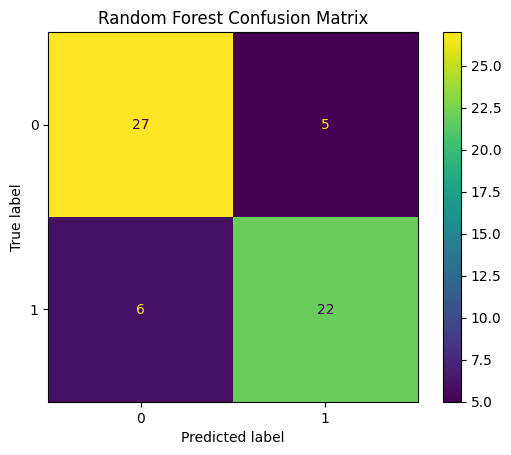

In [55]:
ConfusionMatrixDisplay.from_predictions(y_test, forest_pred)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [56]:
log_coef = pd.Series(
    log_reg.coef_[0],
    index=X.columns
).sort_values()

log_coef.head(10), log_coef.tail(10)

(cp_3        -0.185483
 thalach     -0.174774
 fbs_1       -0.132098
 age         -0.023337
 thal_6.0     0.010316
 restecg_1    0.105942
 exang_1      0.197121
 restecg_2    0.238185
 ca_3.0       0.259701
 chol         0.286810
 dtype: float64,
 slope_3     0.289457
 cp_2        0.304423
 trestbps    0.438793
 oldpeak     0.528130
 slope_2     0.556832
 sex_1       0.574440
 thal_7.0    0.813704
 ca_2.0      0.851462
 ca_1.0      0.876131
 cp_4        0.960324
 dtype: float64)

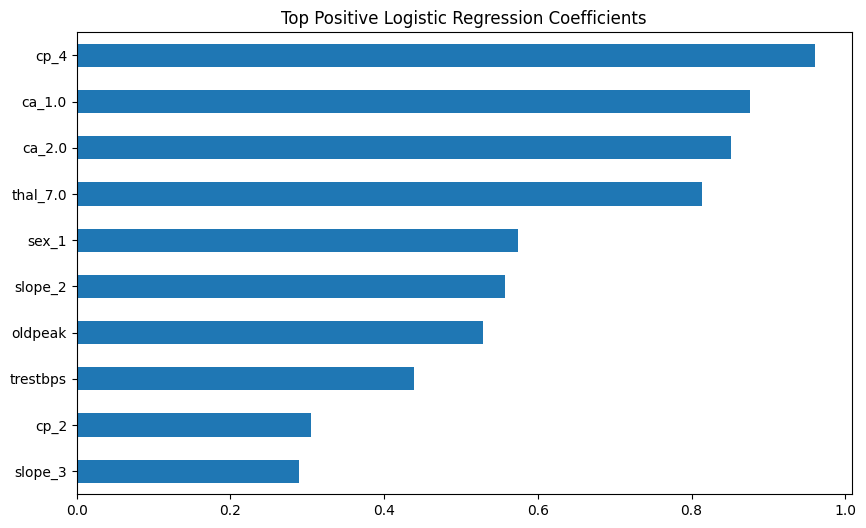

In [57]:
plt.figure(figsize=(10, 6))
log_coef.tail(10).plot(kind="barh")
plt.title("Top Positive Logistic Regression Coefficients")
plt.show()

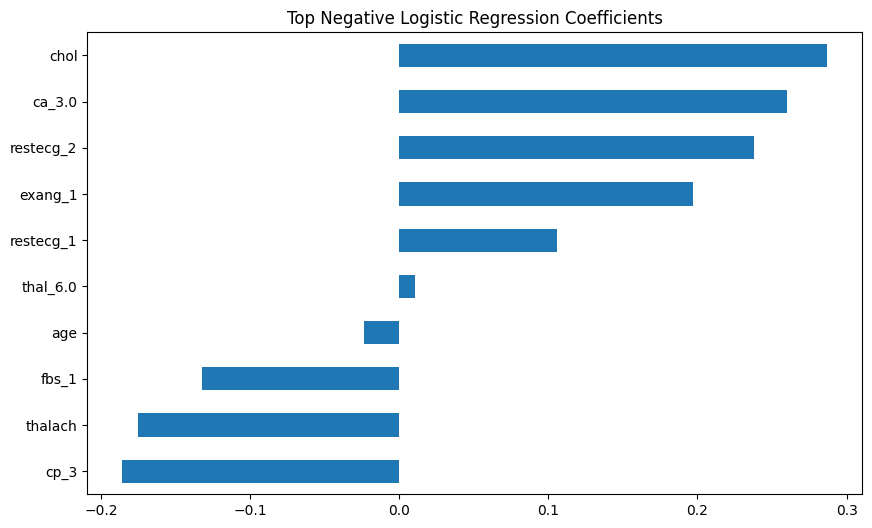

In [58]:
plt.figure(figsize=(10, 6))
log_coef.head(10).plot(kind="barh")
plt.title("Top Negative Logistic Regression Coefficients")
plt.show()

In [59]:
forest_importance = pd.Series(
    forest.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

forest_importance.head(10)

thalach     0.124977
oldpeak     0.116313
thal_7.0    0.109069
cp_4        0.106775
age         0.100105
trestbps    0.083600
chol        0.081194
exang_1     0.048062
slope_2     0.040477
ca_1.0      0.036554
dtype: float64

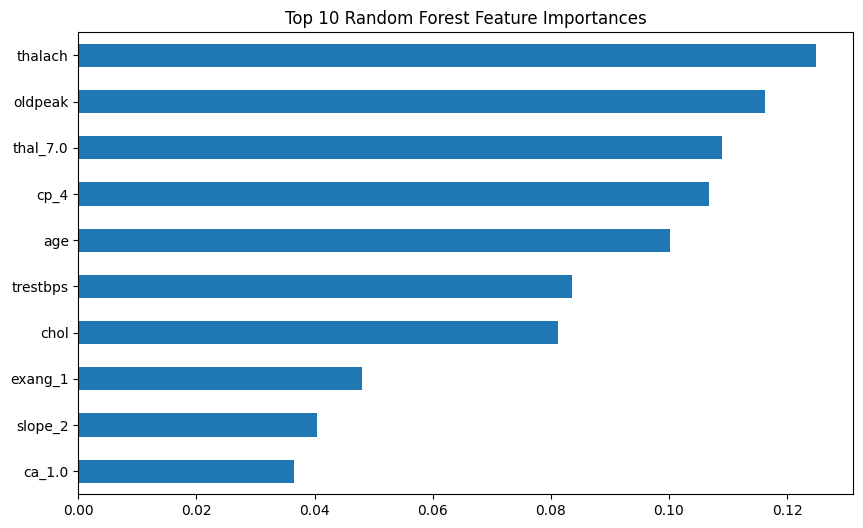

In [60]:
plt.figure(figsize=(10, 6))
forest_importance.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Random Forest Feature Importances")
plt.show()

In [61]:
results.to_csv("model_comparison.csv", index=False)

In [62]:
df_clean.to_csv("heart_disease_cleaned.csv", index=False)

## Conclusion

This project used the UCI Heart Disease dataset to predict whether heart disease was absent or present.

### Main steps
- loaded and cleaned the dataset
- converted the original target into a binary label
- encoded categorical variables
- split the data into training and test sets
- compared a dummy baseline, logistic regression, decision tree, and random forest
- evaluated models using accuracy, precision, recall, F1, ROC-AUC, and confusion matrices

### Main findings
- The baseline model performed the worst, as expected
- The real models learned useful patterns from the features
- Logistic regression provided a strong interpretable baseline
- Random forest may provide stronger performance, depending on the split

### Important note
This is a learning project, not a clinical diagnostic tool.